## IMPORTS

In [3]:
!pip install kagglehub

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import numpy as np
import random
import tensorflow as tf
import seaborn as sns
import re

random.seed(58)
np.random.seed(58)
tf.random.set_seed(58)

## IMPORT DATASET

In [5]:
path = kagglehub.dataset_download("crowdflower/twitter-airline-sentiment")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\cody_\.cache\kagglehub\datasets\crowdflower\twitter-airline-sentiment\versions\4


## LOAD DATASET

In [6]:
csv_path = os.path.join(path, "Tweets.csv")
df = pd.read_csv(csv_path)

print("Dataset shape:", df.shape)
print("Dataset columns:", df.columns)
print("First 5 rows of the dataset:")
print(df.head())

Dataset shape: (14640, 15)
Dataset columns: Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='str')
First 5 rows of the dataset:
             tweet_id airline_sentiment  airline_sentiment_confidence  \
0  570306133677760513           neutral                        1.0000   
1  570301130888122368          positive                        0.3486   
2  570301083672813571           neutral                        0.6837   
3  570301031407624196          negative                        1.0000   
4  570300817074462722          negative                        1.0000   

  negativereason  negativereason_confidence         airline  \
0            NaN                        NaN  Virgin America   
1            NaN                   

## DATA EXPLORATION

#### Identify key columns

In [7]:
text_col = "text"
target_col = "airline_sentiment"

print("Text column:", text_col)
print("Target column:", target_col)

Text column: text
Target column: airline_sentiment


#### Check class distribution

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


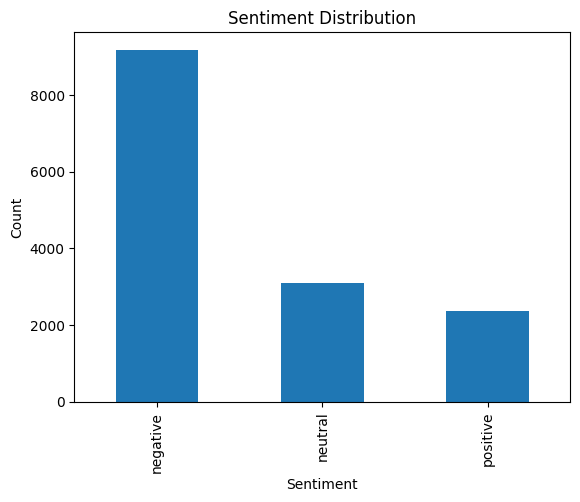

In [8]:
sentiment_counts = df[target_col].value_counts()

print(sentiment_counts)
sentiment_counts.plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

#### Check missing Values

In [9]:
df.isnull().sum()

tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64

#### Sample Tweets

In [10]:
df[text_col].sample(10).tolist()

['@USAirways 1 1/2 hours on hold to customer service without anyone answering is more than ridiculous!',
 '@SouthwestAir @Imaginedragons any info on #DestinationDragons ?? me &amp; @sammi_jon3s need to know..',
 '@united - 75% of a plane\'s passengers boarding in your "Premier" groups might be an indication of a broken process.',
 "@united so what's the solution?",
 "@AmericanAir \nNo one answers phone, delayed/Cancelled Flightled flights. Rude employees. You only get (I'm sorry, we apologize) blah blah blah. Bad",
 "@USAirways Cancelled Flightled flight, 50 person line and one agent helping to rebook. You could've handed this one better. http://t.co/By3vDioSUA",
 '@USAirways @AmericanAir Suggestions , been on hold 2 hrs for flight that is now about to pass departure...Dealing w ny weather, need change',
 '@SouthwestAir baggage delivery at BWI very delayed and unnecessarily chaotic. Disappointing after a long trip! From a frequent traveler',
 '@SouthwestAir Pres/CEO Gary Kelly at #TheR

## DATA PREPROCESSING

#### Keeping the Necessary Columns

In [11]:
tweets = df[[text_col, target_col]].copy()
tweets.head()

,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


#### Checking and removing duplicates

In [12]:
print("Before removing duplicates:", tweets.shape)

tweets = tweets.drop_duplicates()

print("After removing duplicates:", tweets.shape)

Before removing duplicates: (14640, 2)
After removing duplicates: (14452, 2)


#### Cleaning the tweet text

In [13]:
def clean_text(text):
    text = str(text).strip()

    # remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # replace mentions with placeholder
    text = re.sub(r"@\w+", "@user", text)

    # keep hashtag word, remove only #
    text = re.sub(r"#(\w+)", r"\1", text)

    # normalize spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

tweets["clean_text"] = tweets[text_col].apply(clean_text)

tweets[[text_col, "clean_text"]].head(10)

,text,clean_text
0,@VirginAmerica What @dhepburn said.,@user What @user said.
1,@VirginAmerica plus you've added commercials t...,@user plus you've added commercials to the exp...
2,@VirginAmerica I didn't today... Must mean I n...,@user I didn't today... Must mean I need to ta...
3,@VirginAmerica it's really aggressive to blast...,@user it's really aggressive to blast obnoxiou...
4,@VirginAmerica and it's a really big bad thing...,@user and it's a really big bad thing about it
5,@VirginAmerica seriously would pay $30 a fligh...,@user seriously would pay $30 a flight for sea...
6,"@VirginAmerica yes, nearly every time I fly VX...","@user yes, nearly every time I fly VX this “ea..."
7,@VirginAmerica Really missed a prime opportuni...,@user Really missed a prime opportunity for Me...
8,"@virginamerica Well, I didn't…but NOW I DO! :-D","@user Well, I didn't…but NOW I DO! :-D"
9,"@VirginAmerica it was amazing, and arrived an ...","@user it was amazing, and arrived an hour earl..."


#### Encoding sentiment labels

In [14]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
tweets["label"] = label_encoder.fit_transform(tweets[target_col])

print(label_encoder.classes_)
tweets[[target_col, "label"]].head()

['negative' 'neutral' 'positive']


,airline_sentiment,label
0,neutral,1
1,positive,2
2,neutral,1
3,negative,0
4,negative,0


#### Splitting into train and test

In [15]:
from sklearn.model_selection import train_test_split

X = tweets["clean_text"]
y = tweets["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=58,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (11561,)
X_test shape: (2891,)


## TRANSFORMER MODEL

#### Tokenize and pad the text with Keras

In [16]:
!pip install transformers

In [ ]:
from transformers import AutoTokenizer

model_name = "distilbert-base-uncased"
max_len = 64

tokenizer = AutoTokenizer.from_pretrained(model_name)

train_encodings = tokenizer(
    list(X_train),
    truncation=True,
    padding=True,
    max_length=max_len,
    return_tensors="tf"
)

test_encodings = tokenizer(
    list(X_test),
    truncation=True,
    padding=True,
    max_length=max_len,
    return_tensors="tf"
)

print("train input_ids shape:", train_encodings["input_ids"].shape)
print("test input_ids shape:", test_encodings["input_ids"].shape)

d:\SoftwareEng\SEMESTER6\COMP263-Deep Learning\COMP263_Group10\.venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


train input_ids shape: (11561, 50)
test input_ids shape: (2891, 50)


#### Build the Transformer Model

In [18]:
from transformers import TFAutoModelForSequenceClassification

transformer_model = TFAutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_layer_norm.weight', 'vocab_transform.bias', 'vocab_projector.bias', 'vocab_transform.weight', 'vocab_layer_norm.bias']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

#### Compiling the model

In [19]:
transformer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

## MODEL TRAINING

#### Train the Model

In [20]:
history = transformer_model.fit(
    {
        "input_ids": train_encodings["input_ids"],
        "attention_mask": train_encodings["attention_mask"]
    },
    y_train,
    validation_split=0.2,
    epochs=2,
    batch_size=16
)

Epoch 1/2
Cause: for/else statement not yet supported
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: for/else statement not yet supported
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert



578/578 [==============================] - 747s 1s/step - loss: 0.5240 - accuracy: 0.7947 - val_loss: 0.4212 - val_accuracy: 0.8344
Epoch 2/2
578/578 [==============================] - 682s 1s/step - loss: 0.3181 - accuracy: 0.8833 - val_loss: 0.4278 - val_accuracy: 0.8383


## EVALUATION

#### Evaluating the model

In [21]:
test_loss, test_accuracy = transformer_model.evaluate(
    {
        "input_ids": test_encodings["input_ids"],
        "attention_mask": test_encodings["attention_mask"]
    },
    y_test
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

91/91 [==============================] - 44s 486ms/step - loss: 0.4406 - accuracy: 0.8329
Test Loss: 0.4406389594078064
Test Accuracy: 0.832929790019989


#### Making predictions

In [22]:
predictions = transformer_model.predict(
    {
        "input_ids": test_encodings["input_ids"],
        "attention_mask": test_encodings["attention_mask"]
    }
)

y_pred_classes = np.argmax(predictions.logits, axis=1)

91/91 [==============================] - 49s 492ms/step


#### Classification report

In [23]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_classes,
    target_names=label_encoder.classes_,
    zero_division=0
))

              precision    recall  f1-score   support

    negative       0.89      0.90      0.90      1818
     neutral       0.71      0.67      0.69       613
    positive       0.75      0.78      0.77       460

    accuracy                           0.83      2891
   macro avg       0.79      0.78      0.78      2891
weighted avg       0.83      0.83      0.83      2891



#### Confusion Matrix

[[1640  124   54]
 [ 140  408   65]
 [  59   41  360]]


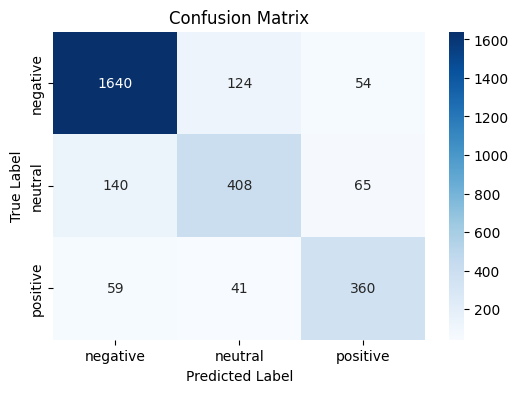

In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_classes)
print(cm)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

#### Plotting training graphs

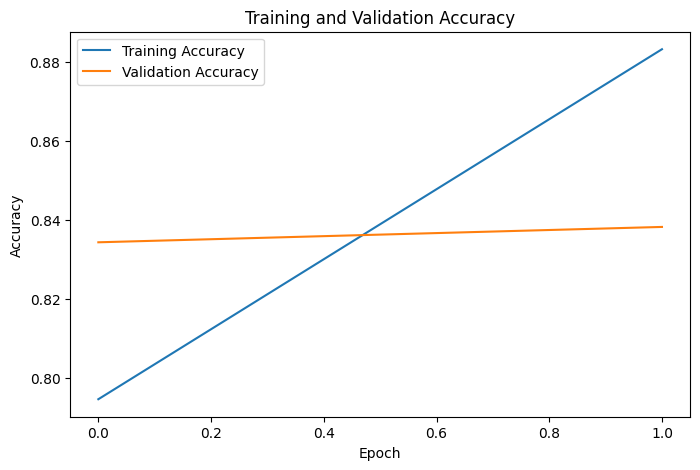

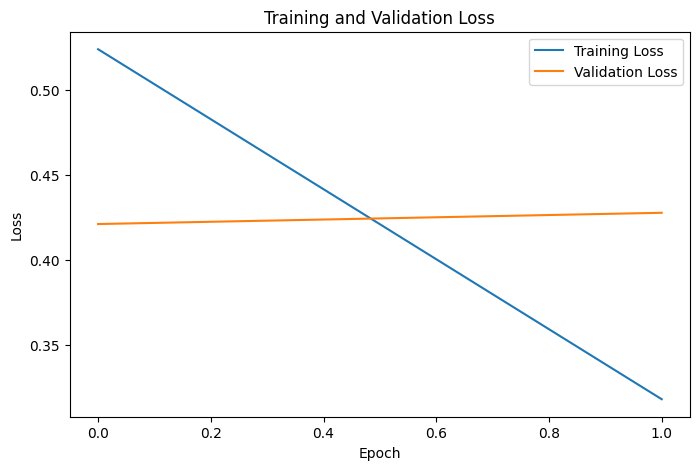

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()